In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
from numpy import random 
import ast
from scipy.fft import fft, fftfreq, fftshift
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tqdm import tqdm 

#Function to convert an array in the form [R1, R2, R3, I1, I2, I3] to [R1+I1, R2+I2, R3+I3]
def output_parse(array):
    final_prediction = []
    transpose = int(len(array)/2)
    for i in range(transpose):
        real = array[i]
        imag = array[i+transpose]
        add = complex(real, imag)
        final_prediction.append(add)
    return final_prediction

In [2]:
data = pd.read_csv("training_data.csv")

In [3]:
x = data["Coupled"]
y = data["FID"]

#Each FID is stored as a long string in the CSV file
#This loop converts each long string into a list of complex values
for i in tqdm(range(len(x))):
    x[i] = ast.literal_eval(x[i])
    y[i] = ast.literal_eval(y[i])

100%|██████████| 25000/25000 [02:24<00:00, 173.16it/s]


In [4]:
x_input = []
y_output = []

#This loop converts our training data from the form [R1+I1, R2+I2, R3+I3] to [R1, R2, R3, I1, I2, I3]
#This is because the model cannot work with complex numbers, 
#hence each complex value must be split into real and imaginary components.
for i in tqdm(range(len(x))):
    x_real_add = []
    x_imag_add = []
    y_real_add = []
    y_imag_add = []
    for j in range(len(x[i])):
        x_real_add.append(x[i][j].real)
        x_imag_add.append(x[i][j].imag)
        y_real_add.append(y[i][j].real)
        y_imag_add.append(y[i][j].imag)
    x_final_add = np.concatenate((x_real_add, x_imag_add), axis=0)
    y_final_add = np.concatenate((y_real_add, y_imag_add), axis=0)
    x_final_add = x_final_add.transpose()
    y_final_add = y_final_add.transpose()
    x_input.append(x_final_add)
    y_output.append(y_final_add)

x_input = np.array(x_input)
y_output = np.array(y_output)

x_input = x_input.reshape(-1, 1024)
y_output = y_output.reshape(-1, 1024)

100%|██████████| 25000/25000 [00:59<00:00, 418.86it/s]


In [5]:
model = Sequential([
    Input(shape=(1024,)),                               
    Dense(256, activation="relu"),  
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.1),
    Dense(256, activation="relu"),  
    Dense(1024)                    
])

lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1) #Slows the learning rate when the decrease in loss slows down
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) #Stops training when loss decrease stops
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(x_input, y_output, epochs=100, batch_size=32, validation_split=0.2, callbacks=[lr_scheduler, early_stopping])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0015 - mae: 0.0168 - val_loss: 3.8529e-04 - val_mae: 0.0104 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.5725e-04 - mae: 0.0106 - val_loss: 1.4175e-04 - val_mae: 0.0074 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.6682e-04 - mae: 0.0079 - val_loss: 9.7274e-05 - val_mae: 0.0063 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.2423e-04 - mae: 0.0069 - val_loss: 8.3347e-05 - val_mae: 0.0058 - learning_rate: 0.0010
Epoch 5/100
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0717e-04 - mae: 0.0064
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.0716e-04 - mae: 0.0064 - val_loss: 7.6459e-05 - val_mae: 0.0055 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 9.2047e-05 - mae: 0.0059 - val_loss: 6

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       263,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971,458 (7.52 MB)

 Trainable params: 657,152 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,314,306 (5.01 MB)

In [7]:
#Input spectra parameters
relaxation = 500
A = 0.5
points = 512
sweep_width = 10000
duration = points / sweep_width
tpi = 2 * np.pi
reference_frequency = 500 * 10**6
number_of_spectra = 50000
J_upper = 4000
J_lower = 2800
ppm_upper = 800
ppm_lower = -800

#Generating a coupled FID and its uncoupled counterpart to assess the model in the time domain
#This is harder to visualise
ppm = random.randint(ppm_lower, ppm_upper)
desired_ppm = ppm / 100
larmor = ((reference_frequency * desired_ppm) / 10**6)
t = np.linspace(0, duration, points)
FID = A * np.exp(relaxation * -t) * np.exp(1j * tpi * larmor * t)
for j in range(len(FID)):
        FID[j] = FID[j] + random.normal(loc=0, scale=0.01)
couple_degree = random.randint(1,3) 
J = random.randint(J_lower, J_upper)
coupled_FID = FID * (np.cos(0.5 * J * t))**couple_degree

Coupled FID


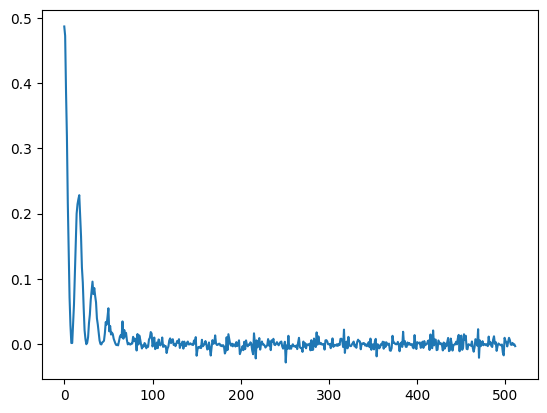

In [8]:
print("Coupled FID")
plt.plot(coupled_FID)

Uncoupled FID


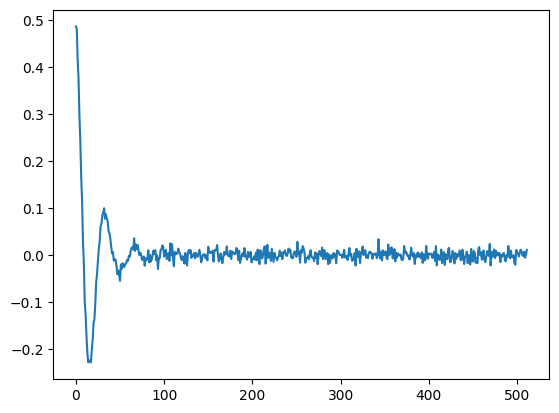

In [9]:
print("Uncoupled FID")
plt.plot(FID)

Peak PPM: 0.5859375


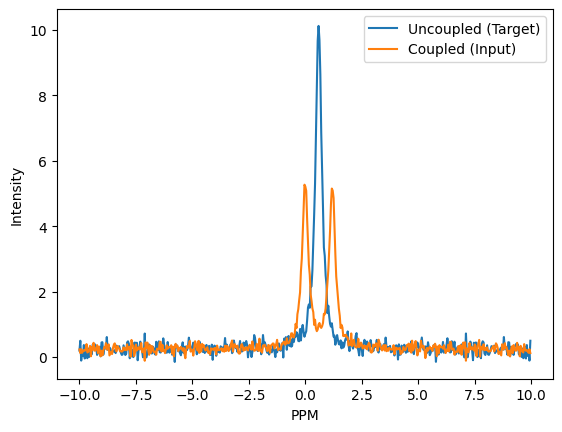

In [10]:
#Plotting the FFT of both the coupled and the uncoupled FIDs
spectrum = fftshift(fft(FID))
spectrum2 = fftshift(fft(coupled_FID))
x_axis = fftshift(fftfreq(points, duration / points))
ppm = ((x_axis) / (reference_frequency / 10**6))
print("Peak PPM: "  + str(ppm[spectrum.argmax()]))
plt.figure()
plt.plot(np.real(ppm), np.real(spectrum), label="Uncoupled (Target)")
plt.plot(np.real(ppm), np.real(spectrum2),label="Coupled (Input)")
plt.xlabel("PPM")
plt.ylabel("Intensity")
plt.legend()
plt.show()

In [ ]:
#Takes the coupled FID generated above and rearranges it to the form [R1, R2, R3, I1, I2, I3]
input = []
for i in range(len(coupled_FID)):
    input.append(coupled_FID[i].real)

for j in range((len(coupled_FID))):
    input.append(coupled_FID[j].imag)

input = np.array(input)
input = input.reshape(1, -1)
prediction = model.predict(input)
output = []
for i in range(len(prediction[0])):
    output.append(prediction[0][i])

#Rearranges the model output to the form [R1+I1, R2+I2]
final_output = output_parse(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Uncoupled FID


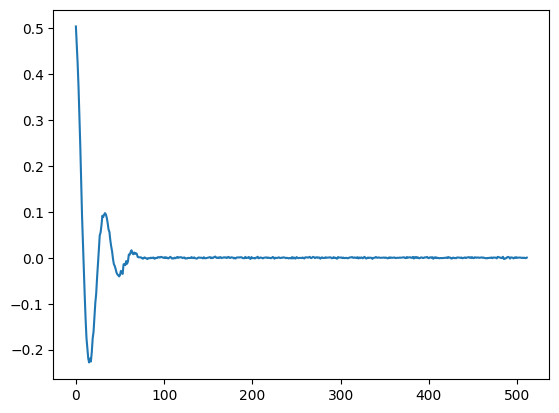

In [ ]:
print("Predicted uncoupled FID")
plt.plot(final_output)

Predicted spectrum
Predicted peak PPM:  0.5859375


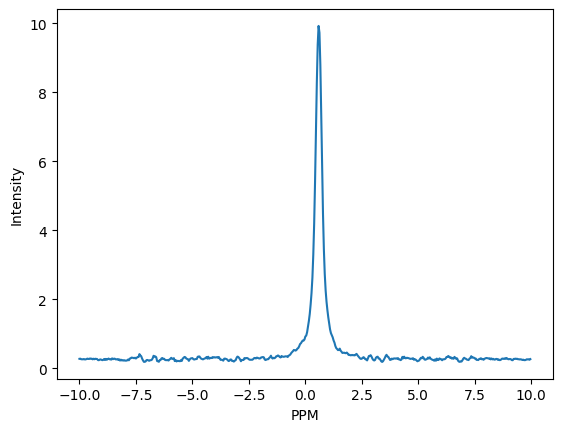

In [13]:
print("Predicted spectrum")
spectrum = fftshift(fft(final_output))
print("Predicted peak PPM:  "+ str(ppm[spectrum.argmax()]))
plt.figure()
plt.plot(np.real(ppm), np.real(spectrum))
plt.xlabel("PPM")
plt.ylabel("Intensity")
plt.show()

*************************** Verification example 1 ***************************
INPUT: 
Peak PPM: 4.1015625


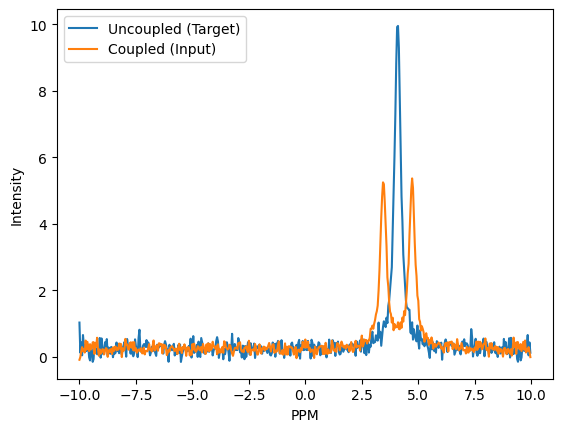

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
PREDICTION: 
Peak PPM: 4.1015625


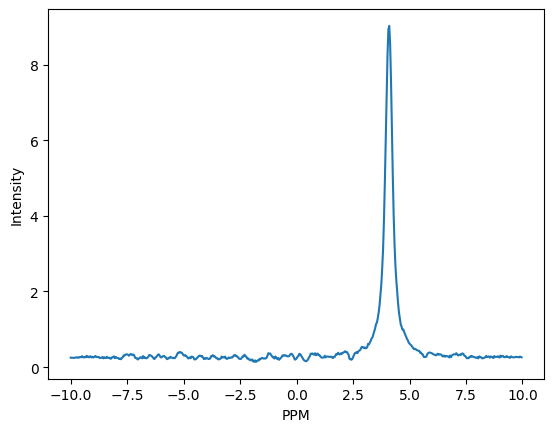




*************************** Verification example 2 ***************************
INPUT: 
Peak PPM: 5.234375


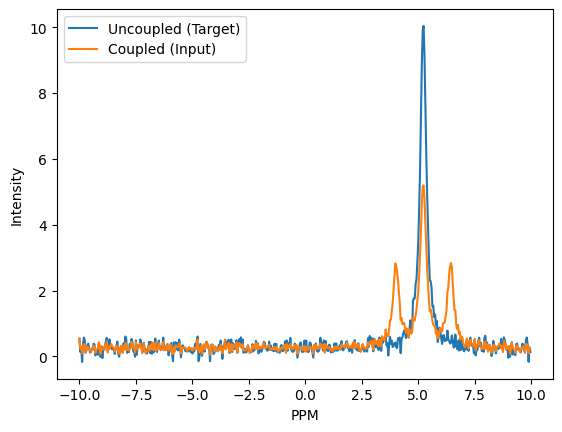

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
PREDICTION: 
Peak PPM: 5.234375


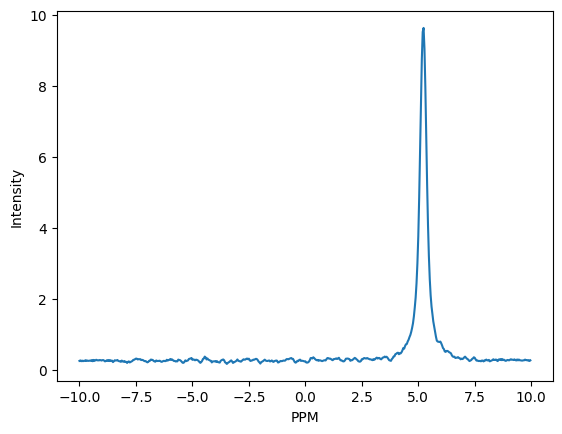




*************************** Verification example 3 ***************************
INPUT: 
Peak PPM: -2.6171875


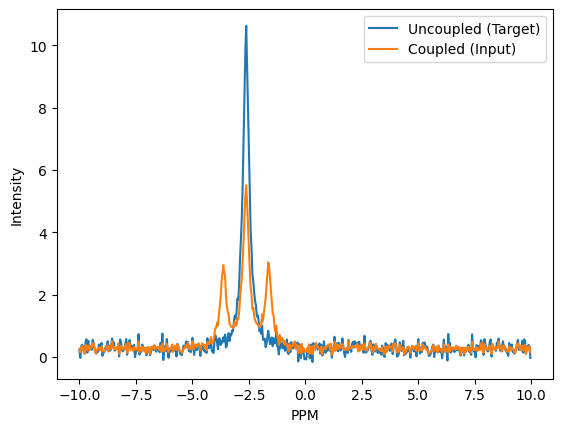

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: -2.6171875


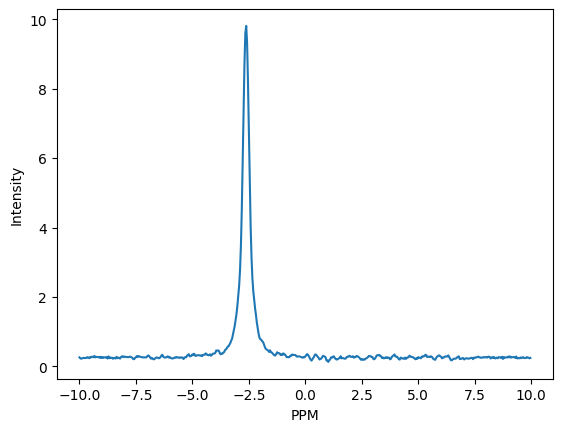




*************************** Verification example 4 ***************************
INPUT: 
Peak PPM: 7.5390625


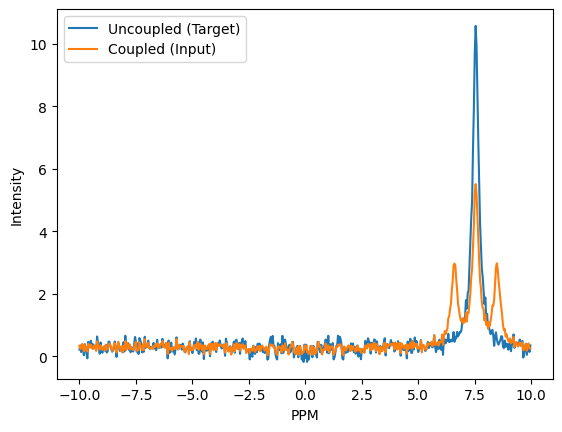

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
PREDICTION: 
Peak PPM: 7.5390625


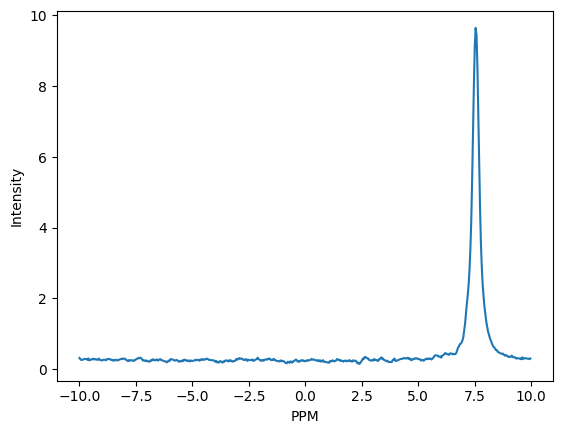




*************************** Verification example 5 ***************************
INPUT: 
Peak PPM: 7.6953125


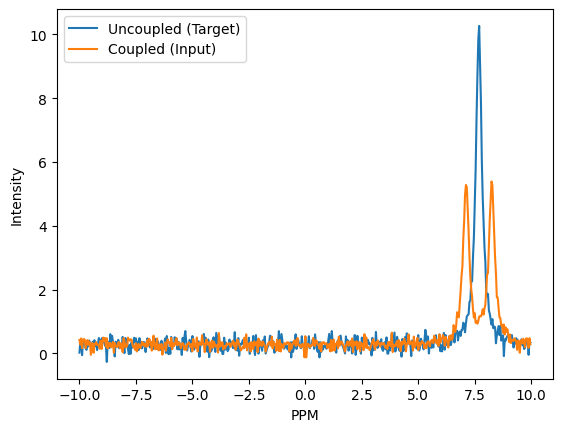

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
PREDICTION: 
Peak PPM: 7.6953125


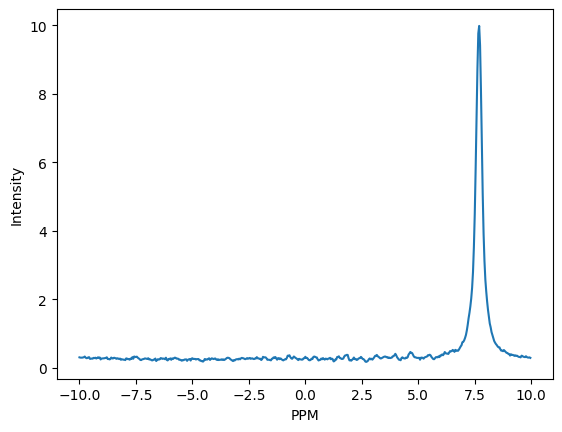




*************************** Verification example 6 ***************************
INPUT: 
Peak PPM: 7.421875


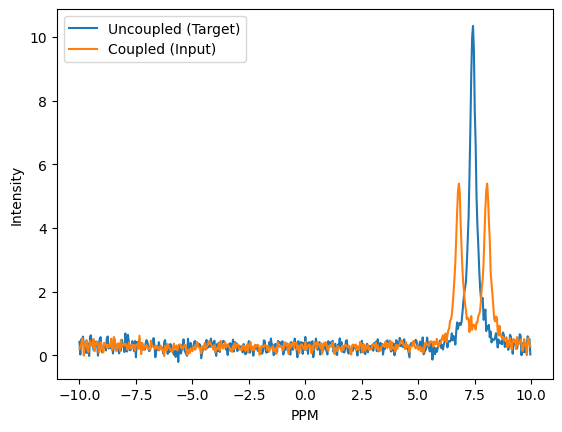

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: 7.421875


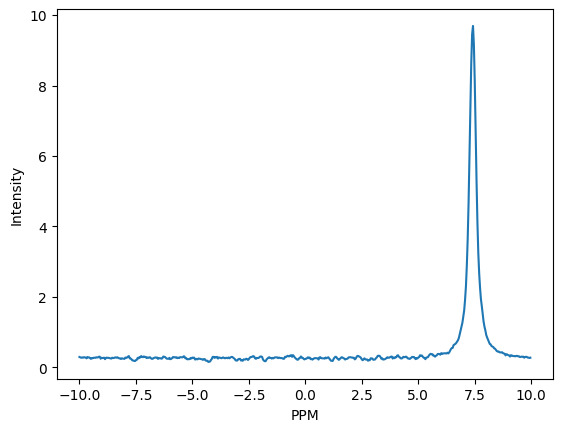




*************************** Verification example 7 ***************************
INPUT: 
Peak PPM: -7.2265625


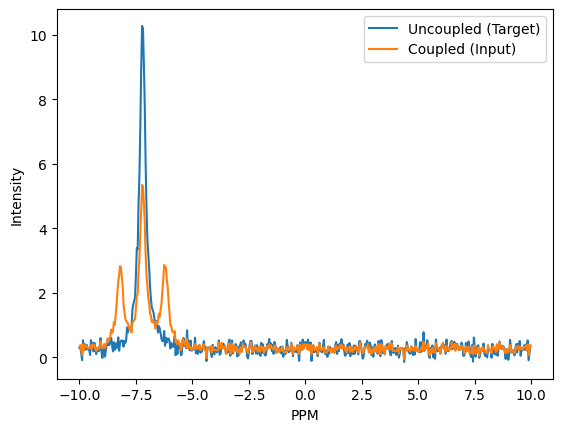

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: -7.1875


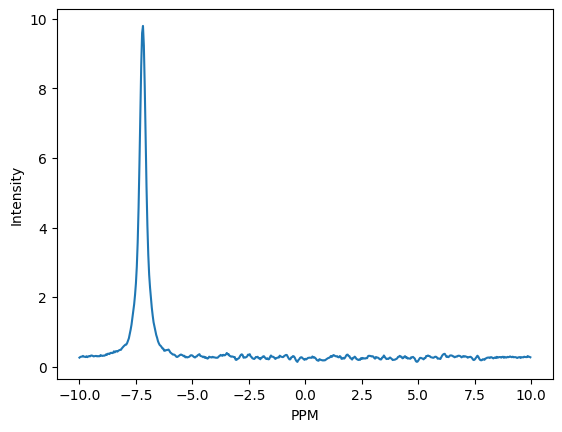




*************************** Verification example 8 ***************************
INPUT: 
Peak PPM: 1.2109375


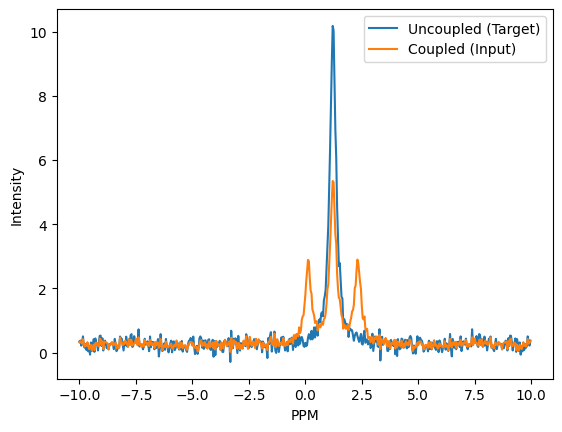

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: 1.2109375


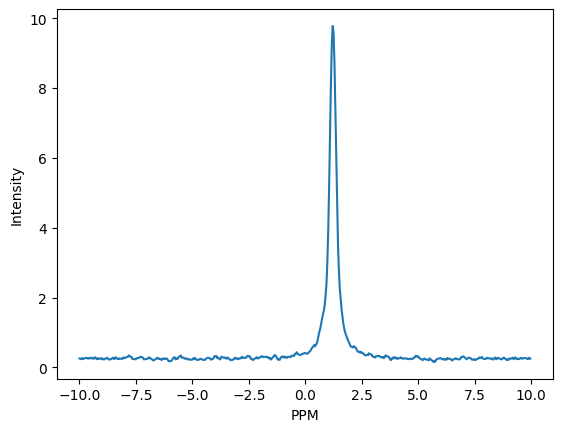




*************************** Verification example 9 ***************************
INPUT: 
Peak PPM: -6.2890625


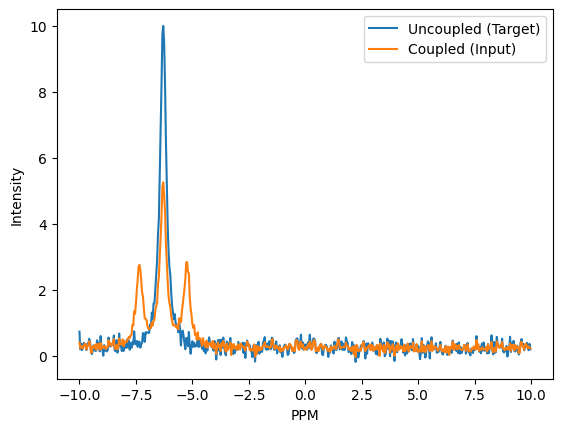

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: -6.2890625


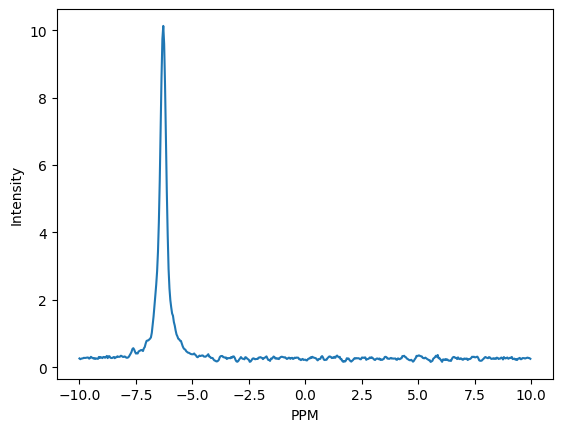




*************************** Verification example 10 ***************************
INPUT: 
Peak PPM: -2.1875


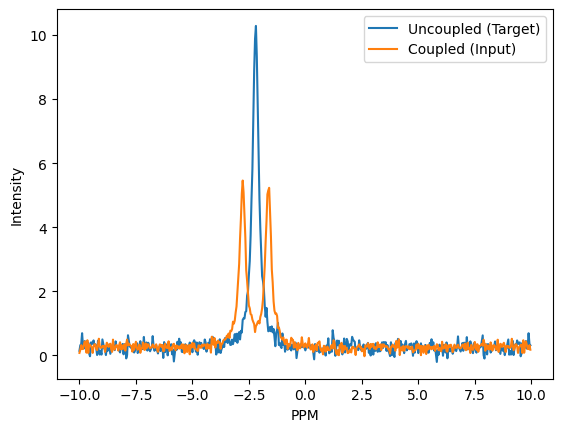

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
PREDICTION: 
Peak PPM: -2.1875


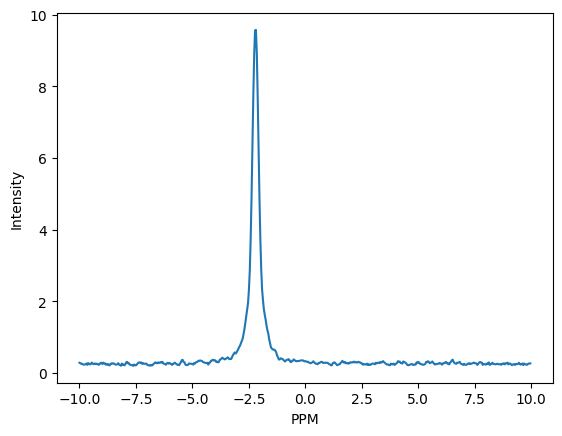

In [ ]:
#Verification
#Plots multiple spectra, showing the input and expected outputs - followed by the real output for comparison.
for i in range(10):
    print("*************************** Verification example " + str(i + 1) + " ***************************")
    ppm = random.randint(ppm_lower, ppm_upper)
    desired_ppm = ppm / 100
    larmor = ((reference_frequency * desired_ppm) / 10**6)
    t = np.linspace(0, duration, points)
    FID = A * np.exp(relaxation * -t) * np.exp(1j * tpi * larmor * t)
    for j in range(len(FID)):
        FID[j] = FID[j] + random.normal(loc=0, scale=0.01)
    couple_degree = random.randint(1,3) 
    J = random.randint(J_lower, J_upper)
    coupled_FID = FID * (np.cos(0.5 * J * t))**couple_degree

    spectrum = fftshift(fft(FID))
    spectrum2 = fftshift(fft(coupled_FID))
    x_axis = fftshift(fftfreq(points, duration / points))
    ppm = ((x_axis) / (reference_frequency / 10**6))
    print("INPUT: ")
    print("Peak PPM: "  + str(ppm[spectrum.argmax()]))
    plt.figure()
    plt.plot(np.real(ppm), np.real(spectrum), label="Uncoupled (Target)")
    plt.plot(np.real(ppm), np.real(spectrum2), label="Coupled (Input)")
    plt.xlabel("PPM")
    plt.ylabel("Intensity")
    plt.legend()
    plt.show()

    input = []
    for i in range(len(coupled_FID)):
        input.append(coupled_FID[i].real)

    for j in range((len(coupled_FID))):
        input.append(coupled_FID[j].imag)

    input = np.array(input)
    input = input.reshape(1, -1)
    prediction = model.predict(input)
    output = []
    for i in range(len(prediction[0])):
        output.append(prediction[0][i])

    final_output = output_parse(output)
    final_spectrum = fftshift(fft(final_output))
    print("PREDICTION: ")
    print("Peak PPM: "  + str(ppm[final_spectrum.argmax()]))
    plt.figure()
    plt.plot(np.real(ppm), np.real(final_spectrum))
    plt.xlabel("PPM")
    plt.ylabel("Intensity")
    plt.show()
    print("")
    print("")
    print("")

    